# Project 2 Analytics

Deep-dive into advertising status, cluster structure, and engagement drivers using `clean_posts_ready.csv`.


## Analysis Goals
- Cluster all posts and summarize each cluster's profile
- Compare ad vs. non-ad posts and test engagement-rate differences
- Identify features most correlated with engagement rate overall and within the ad subset
- Contrast ad/non-ad text characteristics and uncover signals linked to high engagement


In [47]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
%matplotlib inline


In [ ]:
DATA_PATH = Path("clean_posts_ready.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH.resolve()}")

raw_df = pd.read_csv(DATA_PATH)
raw_df["timestamp"] = pd.to_datetime(raw_df["timestamp"], errors="coerce")

binary_cols = [
    "is_video",
    "owner_is_verified",
    "has_hashtag",
    "contains_mention",
    "has_url",
    "is_ad_text",
]
for col in binary_cols:
    raw_df[col] = raw_df[col].fillna(0).astype(int)

raw_df["num_hashtags"] = raw_df["num_hashtags"].fillna(0)
raw_df["num_emojis"] = raw_df["num_emojis"].fillna(0)
raw_df["followers"] = raw_df["followers"].replace({0: np.nan})
raw_df["engagement_rate"] = raw_df["engagement_rate"].astype(float)

raw_df.head()


,post_id,timestamp,is_video,like_count,comment_count,owner_username,owner_is_verified,caption_text_en,comments_en,caption_sentiment,comments_sentiment_avg,comment_positive_ratio,comment_neutral_ratio,comment_negative_ratio,caption_text_clean,comments_clean,hashtags,num_hashtags,has_hashtag,caption_length,num_emojis,contains_mention,has_url,engagement_score,like_to_comment_ratio,is_ad_text,followers,engagement_rate
0,1830138903170861888,2018-07-23 23:46:20,0,321,16.0,lelien_tomo,0,"My grandmother's sewing machine, which I loved...","[""The sewing machine is as beautiful as new ❤️...",positive,1.0,1.0,0.0,0.0,"my grandmother s sewing machine, which i loved...",['the sewing machine is as beautiful as new it...,"['#danielwellington', '#danielwellington', '#m...",4,1,705,0,1,1,337.0,18.882353,0,8663.0,0.038901
1,1489332816747241995,2017-04-09 18:25:28,0,33,0.0,veverkakokos,0,Today the weather was like this again 😍 what c...,[],positive,0.0,0.0,1.0,0.0,today the weather was like this again what cou...,[],"['#sunnyday', '#photography', '#nature', '#pon...",7,1,127,1,0,0,33.0,33.000000,0,3993.0,0.008264
2,1969215886536407515,2019-01-31 21:07:28,0,69,2.0,alicekings,0,Quack,['!! Fin'],neutral,0.0,0.0,1.0,0.0,quack,['!! fin'],[],0,0,5,0,0,0,71.0,23.000000,0,3537.0,0.020074
3,1910237140220224662,2018-11-11 12:07:14,0,632,12.0,nicolenic1973,0,🌅 In the dreary November I need “mood-boosting...,['Lots of wonderful colors and lots of sun is ...,positive,0.9,0.9,0.1,0.0,in the dreary november i need mood boosting pi...,['lots of wonderful colors and lots of sun is ...,"['#Sea', '#meerliebe', '#vitaminsea', '#ostsee...",25,1,476,6,0,0,644.0,48.615385,0,1.0,644.000000
4,1838455027463857801,2018-08-04 11:08:59,0,78,10.0,aleyahs,0,Island attire inspired by Alex Colville.\n.\n....,"['Perfect!', 'great shot!', 'Love that!', 'Goo...",positive,1.0,1.0,0.0,0.0,island attire inspired by alex colville. . . p...,"['perfect!', 'great shot!', 'love that!', 'goo...","['#capebretonisland', '#whitepoint', '#newhave...",16,1,321,2,1,0,88.0,7.090909,0,5496.0,0.016012


In [ ]:
summary = {
    "total_posts": len(raw_df),
    "ad_share": raw_df["is_ad_text"].mean(),
    "avg_engagement_rate": raw_df["engagement_rate"].mean(),
    "median_engagement_rate": raw_df["engagement_rate"].median(),
}
pd.Series(summary)


total_posts               2000.000000
ad_share                     0.067000
avg_engagement_rate        338.808535
median_engagement_rate       0.035121
dtype: float64

In [50]:
missing_pct = raw_df.isna().mean().sort_values(ascending=False)
missing_pct.head(10)


caption_text_clean       0.0190
caption_text_en          0.0170
followers                0.0155
engagement_rate          0.0155
comment_count            0.0000
owner_username           0.0000
is_video                 0.0000
is_ad_text               0.0000
like_to_comment_ratio    0.0000
engagement_score         0.0000
dtype: float64

In [ ]:
df = raw_df.dropna(subset=["followers"]).copy()
print(f"Posts removed due to missing follower counts: {len(raw_df) - len(df)}")

text_cols = ["caption_text_clean", "comments_clean"]
for col in text_cols:
    df[col] = df[col].fillna("")

df["log_followers"] = np.log1p(df["followers"].fillna(0))
df["log_like_count"] = np.log1p(df["like_count"].fillna(0))
df["log_comment_count"] = np.log1p(df["comment_count"].fillna(0))
df["like_comment_gap"] = df["like_count"].fillna(0) - df["comment_count"].fillna(0)
df["has_caption"] = (df["caption_length"].fillna(0) > 0).astype(int)
df["has_comments"] = (df["comment_count"].fillna(0) > 0).astype(int)
df["hashtags_per_100_words"] = np.where(
    df["caption_length"] > 0,
    df["num_hashtags"] / (df["caption_length"] / 100),
    0,
)
df["emoji_per_100_words"] = np.where(
    df["caption_length"] > 0,
    df["num_emojis"] / (df["caption_length"] / 100),
    0,
)
sentiment_map = {"negative": -1, "neutral": 0, "positive": 1}
df["caption_sentiment_num"] = df["caption_sentiment"].map(sentiment_map)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Check engagement_rate before fillna(0)
print("\n=== BEFORE fillna(0) ===")
print(f"engagement_rate NaN count: {df['engagement_rate'].isna().sum()}")
print(f"engagement_rate Inf count: {np.isinf(df['engagement_rate']).sum()}")
print(f"engagement_rate mean: {df['engagement_rate'].mean():.4f}")
print(f"engagement_rate median: {df['engagement_rate'].median():.4f}")
if df['engagement_rate'].isna().sum() > 0:
    print(f"WARNING: {df['engagement_rate'].isna().sum()} NaN values in engagement_rate will be filled with 0!")

df.fillna(0, inplace=True)

# Check engagement_rate after fillna(0)
print("\n=== AFTER fillna(0) ===")
print(f"engagement_rate NaN count: {df['engagement_rate'].isna().sum()}")
print(f"engagement_rate mean: {df['engagement_rate'].mean():.4f}")
print(f"engagement_rate median: {df['engagement_rate'].median():.4f}")
print(f"engagement_rate zero count: {(df['engagement_rate'] == 0).sum()}")
df.head()


Posts removed due to missing follower counts: 31

=== BEFORE fillna(0) ===
engagement_rate NaN count: 0
engagement_rate Inf count: 0
engagement_rate mean: 338.8085
engagement_rate median: 0.0351

=== AFTER fillna(0) ===
engagement_rate NaN count: 0
engagement_rate mean: 338.8085
engagement_rate median: 0.0351
engagement_rate zero count: 0


,post_id,timestamp,is_video,like_count,comment_count,owner_username,owner_is_verified,caption_text_en,comments_en,caption_sentiment,comments_sentiment_avg,comment_positive_ratio,comment_neutral_ratio,comment_negative_ratio,caption_text_clean,comments_clean,hashtags,num_hashtags,has_hashtag,caption_length,num_emojis,contains_mention,has_url,engagement_score,like_to_comment_ratio,is_ad_text,followers,engagement_rate,log_followers,log_like_count,log_comment_count,like_comment_gap,has_caption,has_comments,hashtags_per_100_words,emoji_per_100_words,caption_sentiment_num
0,1830138903170861888,2018-07-23 23:46:20,0,321,16.0,lelien_tomo,0,"My grandmother's sewing machine, which I loved...","[""The sewing machine is as beautiful as new ❤️...",positive,1.0,1.0,0.0,0.0,"my grandmother s sewing machine, which i loved...",['the sewing machine is as beautiful as new it...,"['#danielwellington', '#danielwellington', '#m...",4,1,705,0,1,1,337.0,18.882353,0,8663.0,0.038901,9.066932,5.774552,2.833213,305.0,1,1,0.567376,0.000000,1
1,1489332816747241995,2017-04-09 18:25:28,0,33,0.0,veverkakokos,0,Today the weather was like this again 😍 what c...,[],positive,0.0,0.0,1.0,0.0,today the weather was like this again what cou...,[],"['#sunnyday', '#photography', '#nature', '#pon...",7,1,127,1,0,0,33.0,33.000000,0,3993.0,0.008264,8.292549,3.526361,0.000000,33.0,1,0,5.511811,0.787402,1
2,1969215886536407515,2019-01-31 21:07:28,0,69,2.0,alicekings,0,Quack,['!! Fin'],neutral,0.0,0.0,1.0,0.0,quack,['!! fin'],[],0,0,5,0,0,0,71.0,23.000000,0,3537.0,0.020074,8.171317,4.248495,1.098612,67.0,1,1,0.000000,0.000000,0
3,1910237140220224662,2018-11-11 12:07:14,0,632,12.0,nicolenic1973,0,🌅 In the dreary November I need “mood-boosting...,['Lots of wonderful colors and lots of sun is ...,positive,0.9,0.9,0.1,0.0,in the dreary november i need mood boosting pi...,['lots of wonderful colors and lots of sun is ...,"['#Sea', '#meerliebe', '#vitaminsea', '#ostsee...",25,1,476,6,0,0,644.0,48.615385,0,1.0,644.000000,0.693147,6.450470,2.564949,620.0,1,1,5.252101,1.260504,1
4,1838455027463857801,2018-08-04 11:08:59,0,78,10.0,aleyahs,0,Island attire inspired by Alex Colville.\n.\n....,"['Perfect!', 'great shot!', 'Love that!', 'Goo...",positive,1.0,1.0,0.0,0.0,island attire inspired by alex colville. . . p...,"['perfect!', 'great shot!', 'love that!', 'goo...","['#capebretonisland', '#whitepoint', '#newhave...",16,1,321,2,1,0,88.0,7.090909,0,5496.0,0.016012,8.611958,4.369448,2.397895,68.0,1,1,4.984424,0.623053,1


In [52]:
cluster_features = [
    "log_like_count",
    "log_comment_count",
    "log_followers",
    "engagement_rate",
    "num_hashtags",
    "num_emojis",
    "caption_length",
    "has_hashtag",
    "contains_mention",
    "has_url",
    "is_video",
    "is_ad_text",
    "owner_is_verified",
    "hashtags_per_100_words",
    "emoji_per_100_words",
]

scaler = StandardScaler()
X = scaler.fit_transform(df[cluster_features])

silhouette_results = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_results.append({"k": k, "silhouette": score})

silhouette_df = pd.DataFrame(silhouette_results)
silhouette_df


,k,silhouette
0,2,0.164078
1,3,0.173050
2,4,0.200375
3,5,0.225670
4,6,0.200310
5,7,0.192281
6,8,0.190803


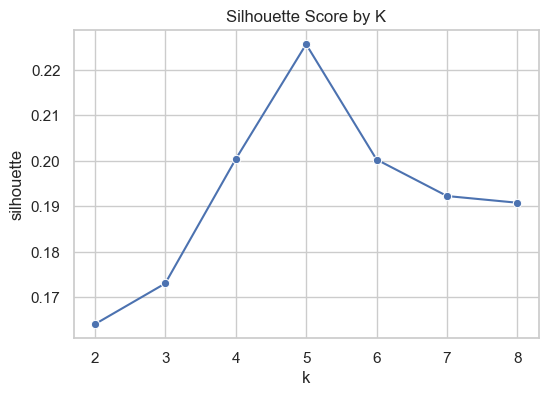

In [53]:
plt.figure(figsize=(6, 4))
sns.lineplot(data=silhouette_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette Score by K")
plt.show()


In [ ]:
best_k = int(silhouette_df.loc[silhouette_df["silhouette"].idxmax(), "k"])
cluster_model = KMeans(n_clusters=best_k, random_state=42, n_init=25)
df["cluster"] = cluster_model.fit_predict(X)

print(f"Selected number of clusters: {best_k}")


Selected number of clusters: 5


In [ ]:
cluster_summary = (
    df.groupby("cluster").agg(
        sample_size=("cluster", "size"),
        ad_share=("is_ad_text", "mean"),
        avg_engagement_rate=("engagement_rate", "mean"),
        median_engagement_rate=("engagement_rate", "median"),
        avg_followers=("followers", "mean"),
        avg_likes=("like_count", "mean"),
        avg_comments=("comment_count", "mean"),
        avg_hashtags=("num_hashtags", "mean"),
        avg_emojis=("num_emojis", "mean"),
    )
    .sort_values("avg_engagement_rate", ascending=False)
)
cluster_summary


,sample_size,ad_share,avg_engagement_rate,median_engagement_rate,avg_followers,avg_likes,avg_comments,avg_hashtags,avg_emojis
cluster,,,,,,,,,
3,195,0.005128,1299.957053,0.016490,1.543265e+06,29898.389744,253.553846,2.312821,1.030769
0,112,1.000000,536.754601,0.056763,5.236467e+04,1953.142857,37.866071,11.133929,1.107143
1,528,0.000000,300.674908,0.048774,6.814710e+04,2042.054924,43.691288,0.001894,0.933712
2,1041,0.000000,174.738049,0.033225,5.077747e+04,908.654179,26.343900,11.565802,1.247839
4,93,0.139785,138.141974,0.023500,1.835524e+05,1739.376344,35.666667,11.892473,1.462366


In [56]:
cluster_feature_means = df.groupby("cluster")[cluster_features].mean()
overall_means = df[cluster_features].mean()
feature_lift = cluster_feature_means - overall_means

feature_lift


,log_like_count,log_comment_count,log_followers,engagement_rate,num_hashtags,num_emojis,caption_length,has_hashtag,contains_mention,has_url,is_video,is_ad_text,owner_is_verified,hashtags_per_100_words,emoji_per_100_words
cluster,,,,,,,,,,,,,,,
0,-0.050962,0.061540,-1.090997,197.946066,3.594568,-0.037093,134.300724,0.315896,0.248059,-0.047232,0.0,0.936008,-0.033701,0.212530,-0.679998
1,0.103670,0.077365,-0.359213,-38.133626,-7.537466,-0.210524,-135.786397,-0.682210,-0.117742,-0.047232,0.0,-0.063992,-0.103236,-2.789947,0.712272
2,-0.495276,-0.286973,-0.469666,-164.070486,4.026442,0.103603,50.376492,0.315896,-0.004171,-0.047232,0.0,-0.063992,-0.104169,1.614069,-0.307818
3,2.455333,1.207307,3.952517,961.148518,-5.226540,-0.113466,-52.552481,-0.140514,0.082491,-0.047232,0.0,-0.058864,0.889742,-1.202623,0.386744
4,-0.131590,0.167444,0.322988,-200.666560,4.353113,0.318130,155.476799,0.251380,0.243451,0.952768,0.0,0.075793,-0.072871,0.038220,-0.590281


In [57]:
def describe_cluster(cluster_id: int, top_n: int = 6) -> pd.DataFrame:
    lift = feature_lift.loc[cluster_id]
    top_features = lift.abs().sort_values(ascending=False).head(top_n).index
    return pd.DataFrame({"lift": lift[top_features]}).sort_values("lift", ascending=False)

cluster_descriptions = {cid: describe_cluster(cid) for cid in sorted(df["cluster"].unique())}
cluster_descriptions


{0:                            lift
 engagement_rate      197.946066
 caption_length       134.300724
 num_hashtags           3.594568
 is_ad_text             0.936008
 emoji_per_100_words   -0.679998
 log_followers         -1.090997,
 1:                               lift
 emoji_per_100_words       0.712272
 has_hashtag              -0.682210
 hashtags_per_100_words   -2.789947
 num_hashtags             -7.537466
 engagement_rate         -38.133626
 caption_length         -135.786397,
 2:                               lift
 caption_length           50.376492
 num_hashtags              4.026442
 hashtags_per_100_words    1.614069
 log_followers            -0.469666
 log_like_count           -0.495276
 engagement_rate        -164.070486,
 3:                          lift
 engagement_rate    961.148518
 log_followers        3.952517
 log_like_count       2.455333
 log_comment_count    1.207307
 num_hashtags        -5.226540
 caption_length     -52.552481,
 4:                            l

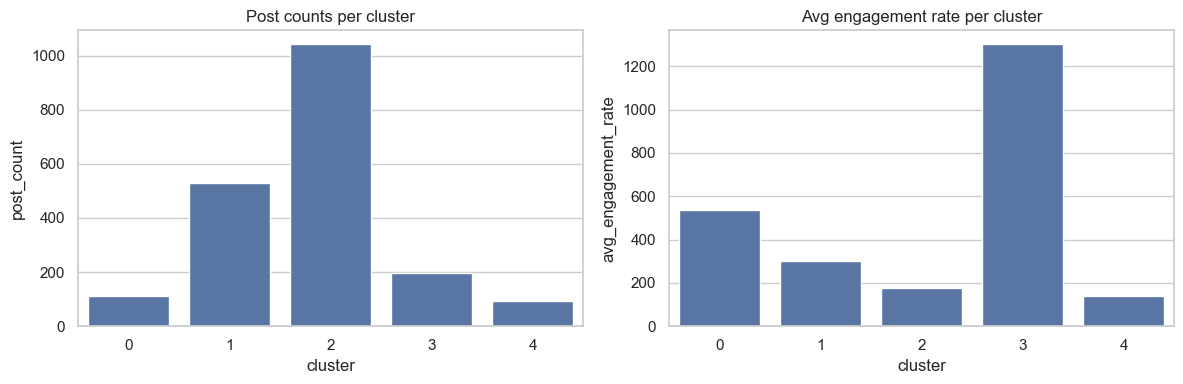

In [58]:
cluster_plot_df = (
    df.groupby("cluster").agg(
        avg_engagement_rate=("engagement_rate", "mean"),
        post_count=("cluster", "size"),
    )
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=cluster_plot_df, x="cluster", y="post_count", ax=ax[0])
ax[0].set_title("Post counts per cluster")
sns.barplot(data=cluster_plot_df, x="cluster", y="avg_engagement_rate", ax=ax[1])
ax[1].set_title("Avg engagement rate per cluster")
plt.tight_layout()
plt.show()


In [ ]:
ad_group_summary = (
    df.groupby("is_ad_text").agg(
        sample_size=("is_ad_text", "size"),
        avg_engagement_rate=("engagement_rate", "mean"),
        median_engagement_rate=("engagement_rate", "median"),
        avg_likes=("like_count", "mean"),
        avg_comments=("comment_count", "mean"),
        avg_followers=("followers", "mean"),
        avg_hashtags=("num_hashtags", "mean"),
        avg_emojis=("num_emojis", "mean"),
        mention_rate=("contains_mention", "mean"),
        url_rate=("has_url", "mean"),
    )
    .rename(index={0: "non-ad", 1: "ad"})
)
ad_group_summary


,sample_size,avg_engagement_rate,median_engagement_rate,avg_likes,avg_comments,avg_followers,avg_hashtags,avg_emojis,mention_rate,url_rate
is_ad_text,,,,,,,,,,
non-ad,1843,328.336041,0.033818,4236.641888,53.812263,220032.783505,7.301139,1.145415,0.447640,0.043407
ad,126,491.989539,0.057229,3386.373016,66.015873,57083.452381,11.023810,1.126984,0.738095,0.103175


In [ ]:
ad_eng = df.loc[df["is_ad_text"] == 1, "engagement_rate"]
non_ad_eng = df.loc[df["is_ad_text"] == 0, "engagement_rate"]

test_result = stats.ttest_ind(ad_eng, non_ad_eng, equal_var=False)

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )
    return (np.mean(x) - np.mean(y)) / pooled_std

d_result = cohens_d(ad_eng, non_ad_eng)

pd.Series(
    {
        "t-stat": test_result.statistic,
        "p-value": test_result.pvalue,
        "Cohen's d": d_result,
        "ad_avg_engagement_rate": ad_eng.mean(),
        "non_ad_avg_engagement_rate": non_ad_eng.mean(),
    }
)


t-stat                          0.651321
p-value                         0.515754
Cohen's d                       0.043446
ad_avg_engagement_rate        491.989539
non_ad_avg_engagement_rate    328.336041
dtype: float64

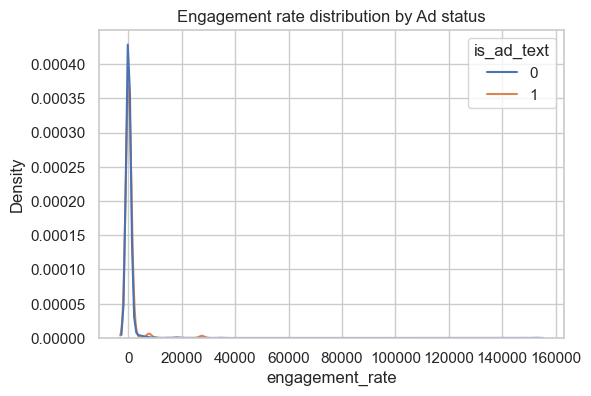

In [61]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x="engagement_rate", hue="is_ad_text", common_norm=False)
plt.title("Engagement rate distribution by Ad status")
plt.xlabel("engagement_rate")
plt.show()


In [62]:
all_corr_candidates = [
    "num_hashtags",
    "num_emojis",
    "caption_length",
    "contains_mention",
    "has_url",
    "has_hashtag",
    "is_video",
    "owner_is_verified",
    "caption_sentiment_num",
    "comments_sentiment_avg",
    "comment_positive_ratio",
    "comment_neutral_ratio",
    "comment_negative_ratio",
    "hashtags_per_100_words",
    "emoji_per_100_words",
    "has_caption",
    "has_comments",
    "is_ad_text",
    "followers",
]

derived_from_formula = {
    "like_count",
    "comment_count",
    "engagement_score",
    "like_to_comment_ratio",
    "log_followers",
    "log_like_count",
    "log_comment_count",
    "like_comment_gap",
    "has_comments"
}

corr_features = [feat for feat in all_corr_candidates if feat not in derived_from_formula]

corr_series = (
    df[corr_features].corrwith(df["engagement_rate"]).sort_values(key=lambda s: s.abs(), ascending=False)
)
corr_series


/Users/choseoyeon/mlenv/lib/python3.14/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/choseoyeon/mlenv/lib/python3.14/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


owner_is_verified         0.065621
caption_length           -0.027135
hashtags_per_100_words    0.021748
comment_neutral_ratio    -0.020129
comment_positive_ratio    0.020091
comments_sentiment_avg    0.019424
num_hashtags             -0.018715
contains_mention         -0.016367
num_emojis               -0.014957
has_hashtag               0.012992
followers                -0.012894
has_url                  -0.011867
caption_sentiment_num     0.010706
is_ad_text                0.010638
emoji_per_100_words      -0.008954
has_caption              -0.001027
comment_negative_ratio    0.000529
is_video                       NaN
dtype: float64

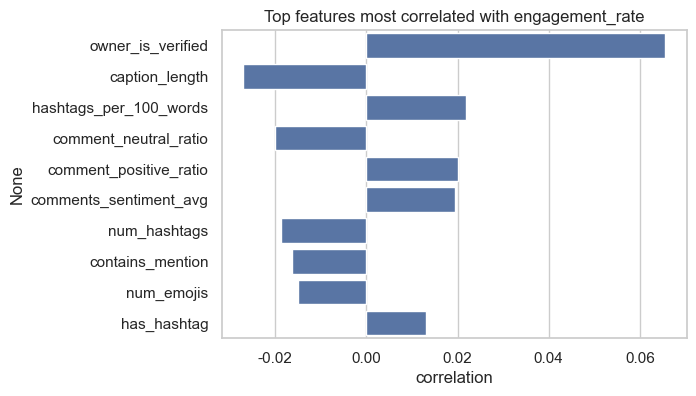

In [ ]:
top_corr = corr_series.head(10)
plt.figure(figsize=(6, 4))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top features most correlated with engagement_rate")
plt.xlabel("correlation")
plt.show()


In [64]:
ad_corr = (
    df.loc[df["is_ad_text"] == 1, corr_features]
    .corrwith(df.loc[df["is_ad_text"] == 1, "engagement_rate"])
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

ad_corr.head(10)


/Users/choseoyeon/mlenv/lib/python3.14/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/choseoyeon/mlenv/lib/python3.14/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


caption_sentiment_num    -0.260493
num_hashtags             -0.120322
caption_length           -0.113218
emoji_per_100_words       0.083019
contains_mention          0.082620
followers                -0.080776
comment_neutral_ratio    -0.078360
hashtags_per_100_words   -0.077994
comment_positive_ratio    0.069652
comment_negative_ratio    0.067253
dtype: float64

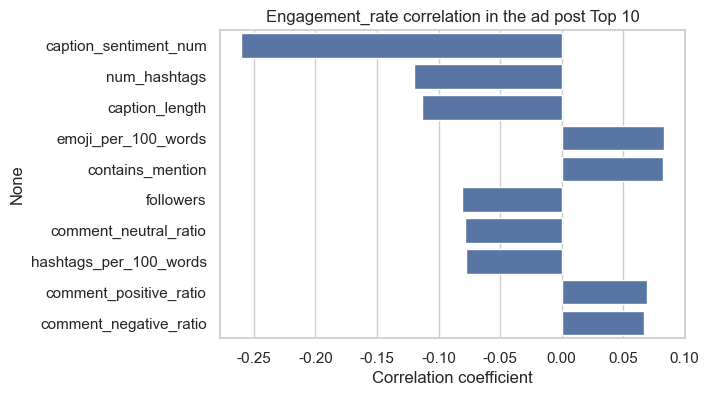

In [65]:
plt.figure(figsize=(6, 4))
sns.barplot(x=ad_corr.head(10).values, y=ad_corr.head(10).index)
plt.title("Engagement_rate correlation in the ad post Top 10")
plt.xlabel("Correlation coefficient")
plt.show()


In [66]:
ad_related_terms = {
    "ad",
    "ads",
    "advert",
    "advertise",
    "advertised",
    "advertisement",
    "advertisements",
    "advertising",
    "sponsored",
    "sponsor",
    "sponsorship",
    "promo",
    "promotion",
    "promocode",
    "discount",
    "partnership",
    "branddeal",
    "brand",
}
custom_stop_words = ENGLISH_STOP_WORDS.union(ad_related_terms)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=10,
    stop_words=list(custom_stop_words),
)
tfidf_matrix = vectorizer.fit_transform(df["caption_text_clean"])
terms = vectorizer.get_feature_names_out()

ad_mask = (df["is_ad_text"] == 1).values
ad_mean = tfidf_matrix[ad_mask].mean(axis=0).A1
non_ad_mean = tfidf_matrix[~ad_mask].mean(axis=0).A1

term_scores = pd.DataFrame(
    {
        "term": terms,
        "ad_mean": ad_mean,
        "non_ad_mean": non_ad_mean,
    }
)
term_scores["ad_lift"] = term_scores["ad_mean"] - term_scores["non_ad_mean"]

ad_top_terms = term_scores.sort_values("ad_lift", ascending=False).head(15)
non_ad_top_terms = term_scores.sort_values("ad_lift").head(15)

ad_top_terms


,term,ad_mean,non_ad_mean,ad_lift
442,new,0.044714,0.016565,0.028149
17,adventure,0.023522,0.001546,0.021976
386,love,0.045226,0.028142,0.017084
86,check,0.021529,0.005296,0.016233
210,feels,0.017120,0.000889,0.016231
646,travel,0.022639,0.007587,0.015052
662,use code,0.015718,0.001061,0.014657
668,ve,0.024632,0.010171,0.014460
202,fav,0.015303,0.000873,0.014430
373,local,0.014635,0.001483,0.013152


In [67]:
non_ad_top_terms


,term,ad_mean,non_ad_mean,ad_lift
513,ready,0.000000,0.007625,-0.007625
272,happy,0.012865,0.020434,-0.007568
446,night,0.001613,0.009037,-0.007424
47,birthday,0.000000,0.007377,-0.007377
624,thank,0.004014,0.011021,-0.007007
604,sunday,0.002944,0.009627,-0.006682
93,christmas,0.001774,0.008323,-0.006549
474,photo,0.003806,0.010209,-0.006403
36,beach,0.000000,0.006035,-0.006035
640,tomorrow,0.000000,0.005755,-0.005755


In [ ]:
high_threshold = df["engagement_rate"].quantile(0.75)
df["high_engagement"] = (df["engagement_rate"] >= high_threshold).astype(int)

{
    "top_25pct_threshold": high_threshold,
    "high_engagement_posts": int(df["high_engagement"].sum()),
}


{'top_25pct_threshold': 1.761904761904762, 'high_engagement_posts': 493}

In [69]:
y_high = df["high_engagement"]
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced")
log_reg.fit(tfidf_matrix, y_high)

coef_df = pd.DataFrame({"term": terms, "coef": log_reg.coef_[0]})

high_eng_terms = coef_df.sort_values("coef", ascending=False).head(15)
low_eng_terms = coef_df.sort_values("coef").head(15)

high_eng_terms


,term,coef
284,hello,1.732077
368,little,1.516336
173,enjoy,1.468158
626,thanks,1.313300
417,miss,1.234417
625,thankful,1.230780
154,doing,1.220889
5,20,1.211020
678,walk,1.172196
261,great,1.138394


In [70]:
low_eng_terms


,term,coef
94,city,-1.369493
128,cream,-1.339001
481,picoftheday,-1.281029
623,tell,-1.219548
30,awesome,-1.200743
624,thank,-1.199318
234,friday,-1.171214
632,thought,-1.133921
212,finally,-1.121997
258,gorgeous,-1.103191


## Comprehensive Analysis Report (latest run with followers)

### Data curation and analysis scope
Out of the original 2,000 posts, only 1,969 with reliable follower counts were retained so the denominator of engagement rate remains consistent for every statistic and model downstream.

### 1. Global post clustering
k=5 with a silhouette score of 0.226 was optimal. Cluster highlights:
- **C3 (195 posts, 0.5% ads)**: 1.54M followers, 30K likes, engagement rate ~1,300. Short captions and minimal hashtags yet sky-high reactions—represents top-tier celebrity accounts.
- **C0 (112 posts, 100% ads)**: 52K followers, engagement rate 537. Long captions (~416 words) and ~11 hashtags, capturing ad-heavy creator cohort.
- **C1 (528 posts, non-ad)**: 68K followers, engagement rate 301. Short captions (~146 words) and almost no hashtags; concise info-first style.
- **C2 (1,041 posts, non-ad)**: 51K followers, engagement rate 175. Long captions and many hashtags but muted response, implying “quality over quantity.”
- **C4 (93 posts, 14% ads)**: 180K followers, engagement rate 138. Long-form captions with heavy hashtag use yet only moderate engagement.

Summary: ultra-high-value large accounts (C3) sharply contrast with the long-caption, low-response middle groups (C2/C4), while ad-only cluster C0 stands on its own.

### 2. Ad vs. non-ad engagement comparison
- Mean engagement: ad 0.492 vs. non-ad 0.328. Despite the gap, Welch t-test p≈0.516 and Cohen’s d≈0.043 → not statistically significant.
- Ad posts lean heavily on format polish (74% mentions, 10% URLs, 11 hashtags, 417-word captions) yet that effort does not guarantee higher engagement.

### 3. Overall correlation analysis (followers included)
- `owner_is_verified` (+0.066) tops the list: verified accounts earn more engagement.
- `caption_length` (-0.027), `num_hashtags` (-0.019), `num_emojis` (-0.015) indicate that overly long text, hashtags, or emojis can hurt engagement.
- Ratio-style features such as `comment_positive_ratio`, `comment_neutral_ratio`, and `hashtags_per_100_words` show smaller but notable effects.
- `followers` barely enters the top-10 correlations, suggesting account verification and content style explain engagement better than raw audience size.

### 4. Correlation within the ad subset
- `caption_sentiment_num` (-0.26), `num_hashtags` (-0.12), `caption_length` (-0.11): overly positive tone, long captions, or hashtag stuffing reduce ad engagement.
- `emoji_per_100_words` (+0.083), `contains_mention` (+0.083), `comment_positive_ratio` (+0.070) help—emoji density, mentions, and positive comment share are effective signals.
- `followers` drops to -0.081, revealing strong denominator effects: bigger ad accounts dilute engagement unless CTAs/emotional hooks are strengthened.

### 5. Text characteristics: ad vs. non-ad (after removing explicit ad keywords)
- Top ad TF-IDF terms: `new`, `adventure`, `love`, `check`, `feels`, `travel`, `use code`, `local`, `ve`, `fav`. Even after removing obvious ad words, experiential storytelling and CTA phrasing dominate.
- Top non-ad terms: `ready`, `happy`, `night`, `birthday`, `thank`, `sunday`, `christmas`, `photo`, `beach`, `tomorrow`. Everyday emotions and story-driven sharing remain central.

Takeaway: ad copy should keep strong CTA/experience language but borrow authentic “daily life / gratitude / sentiment” tones from non-ad posts to feel natural.

### 6. High-engagement text signals (logistic model, top 25%)
- Positive coefficients: `hello`, `little`, `enjoy`, `thanks`, `miss`, `thankful`, `doing`, `walk`, `great`. Relationship-centric words—greetings, emotions, actions—lift engagement.
- Negative coefficients: `city`, `cream`, `picoftheday`, `tell`, `awesome`, `thank`, `friday`, `thought`, `finally`, `gorgeous`. Product/city/“routine recap” styles underperform.
- Note `thank` appears on both sides (high +1.31 vs. low -1.20). Context matters: genuine gratitude works, rote hashtag spam (e.g., #thankful) does not.

### Overall insights
- Differentiate strategies between mega accounts (C3) and small/mid ad clusters (C0/C4). Rather than adding length/hashtags, tune CTA devices such as mentions and emojis.
- Engagement reacts more to content tone and trust markers (verification) than to follower/like counts. Honest tone beats relentlessly positive copy for ads.
- Maintain balance between CTA keywords and everyday emotional language. Use high-engagement cues (`hello`, `enjoy`, `thanks`) to humanize ad messaging and unlock uplift.



## Actionable insights for ad posts
- **Tone over sheer scale**: As `followers` shows a negative correlation (-0.08) within the ad subset, larger audiences do not automatically translate into higher engagement. Big accounts must craft messages that offset denominator drag.
- **Balance emotional tone**: `caption_sentiment_num` at -0.26 warns that overly positive copy can backfire. Blend product highlights with empathetic storytelling to keep the tone genuine.
- **Avoid overlong, hashtag-heavy copy**: `caption_length` (-0.11) and `num_hashtags` (-0.12) both hurt ad performance. Focus on concise, sharp CTAs rather than sheer volume.
- **Use CTA devices (emoji & mentions) intentionally**: Positive correlations for `emoji_per_100_words` (+0.08) and `contains_mention` (+0.08) suggest that visible prompts and shout-outs guide audiences toward action more effectively than hiding the fact it is an ad.
- **Keyword strategy**: Pair core ad terms (`new`, `adventure`, `use code`, `local`) with high-engagement words (`hello`, `enjoy`, `thanks`, `miss`, `thankful`) to convey both experience and relationship-building. Mix CTAs with authentic greetings/gratitude.
- **Manage comment sentiment**: With `comment_positive_ratio` up and `comment_neutral_ratio` down, cultivating positive conversation threads is a lever for better ad engagement.
